Import Library

In [1]:
import os
import pandas as pd
import pickle
import string
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
en_stopwords = stopwords.words("english")
lemmatizer = WordNetLemmatizer()
punctuation = string.punctuation

Display Datasets


In [3]:
df = pd.read_csv('./Datasets/cyberbullying_tweets.csv')
df.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [4]:
df['cyberbullying_type'].value_counts()

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

EDA (Check Missing Value & Drop Duplicate)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   tweet_text          47692 non-null  str  
 1   cyberbullying_type  47692 non-null  str  
dtypes: str(2)
memory usage: 745.3 KB


In [6]:
df.isnull().sum()

tweet_text            0
cyberbullying_type    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(36)

In [8]:
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
len(df)

47656

Preprocess Function

In [9]:
def clean_tweet(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_tag(tag):
    if tag.startswith("JJ"):
        return "a"
    elif tag.startswith("V"):
        return "v"
    elif tag.startswith("R"):
        return "r"
    else:
        return "n"
    
def lemmatizing(tokens):
    lemmatized = []
    tagged = pos_tag(tokens)
    for word, tag in tagged:
        label = get_tag(tag.lower())
        if label:
            result = lemmatizer.lemmatize(word, label)
            lemmatized.append(result)
        else:
            result = lemmatizer.lemmatize(word)
            lemmatized.append(result)
    return lemmatized

def preprocess_sentence(sentence):
    sentence = str(sentence)
    sentence = clean_tweet(sentence)
    sentence = sentence.lower()
    tokens = word_tokenize(sentence)
    tokens = [token for token in tokens if token.isalpha()]
    tokens = [token for token in tokens if token not in en_stopwords]
    tokens = [token for token in tokens if token not in punctuation]
    tokens = lemmatizing(tokens)
    return " ".join(tokens)

Preprocess Sentence


In [10]:
X_processed = df["tweet_text"].apply(preprocess_sentence)
y = df["cyberbullying_type"]

Feature Engineering TF-IDF

In [11]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=3)
X_tfidf = vectorizer.fit_transform(X_processed)

Split Data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [13]:
MODEL_PATH = './Model/logistic_regression_classifier.pkl'
VECTORIZER_PATH = './Model/tfidf_vectorizer.pkl'

Train Model & Evaluation Function

In [14]:
def train_model():
    classifier = LogisticRegression(max_iter=1000, random_state=42)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    print("=== Evaluation Results (Logistic Regression) ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    
    print("Classification Report (Precision, Recall, F1-Score):")
    print(classification_report(y_test, y_pred))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    cc = classifier.classes_

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=cc, yticklabels=cc)
    plt.title('Confusion Matrix - Logistic Regression', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    with open(MODEL_PATH, 'wb') as f:
        pickle.dump(classifier, f)
    with open(VECTORIZER_PATH, 'wb') as f:
        pickle.dump(vectorizer, f)
        
    return classifier, vectorizer

Menu & Test Analyze Comments Function

In [15]:
def write_statement():
    statement = input("Input Comment: ")
    if len(statement.split()) < 2:
        print("Invalid Input! Please enter 2 or more words.")
        return ""
    return statement

def show_pos_tag(statement):
    print("\nPOS_TAG")
    sentence = clean_tweet(statement).lower()
    tokens = word_tokenize(sentence)
    tagged = pos_tag(tokens)
    for word, tag in tagged:
        print(f"-{word}: {tag}")

def analyze_statement(statement, classifier, vectorizer):
    if len(statement) == 0:
        print("\nThere is no comment to analyze. Please input a valid comment.")
        return
    
    show_pos_tag(statement)
    processed_statement = preprocess_sentence(statement)
    statement_tfidf = vectorizer.transform([processed_statement])

    prediction = classifier.predict(statement_tfidf)[0]
    probabilities = classifier.predict_proba(statement_tfidf)[0]
    max_prob = max(probabilities) * 100

    print(f"\nPrediction Comment: {prediction}, Confidence: {max_prob:.2f}%")

Main Program Testing


Your Comment: -
1. Write your comment
2. Analyze your comment
3. Exit
=== Evaluation Results (Logistic Regression) ===
Accuracy: 82.61%

Classification Report (Precision, Recall, F1-Score):
                     precision    recall  f1-score   support

                age       0.96      0.97      0.96      1602
          ethnicity       0.99      0.98      0.98      1636
             gender       0.91      0.82      0.86      1514
  not_cyberbullying       0.60      0.56      0.58      1624
other_cyberbullying       0.59      0.69      0.63      1594
           religion       0.95      0.95      0.95      1562

           accuracy                           0.83      9532
          macro avg       0.83      0.83      0.83      9532
       weighted avg       0.83      0.83      0.83      9532

Confusion Matrix:


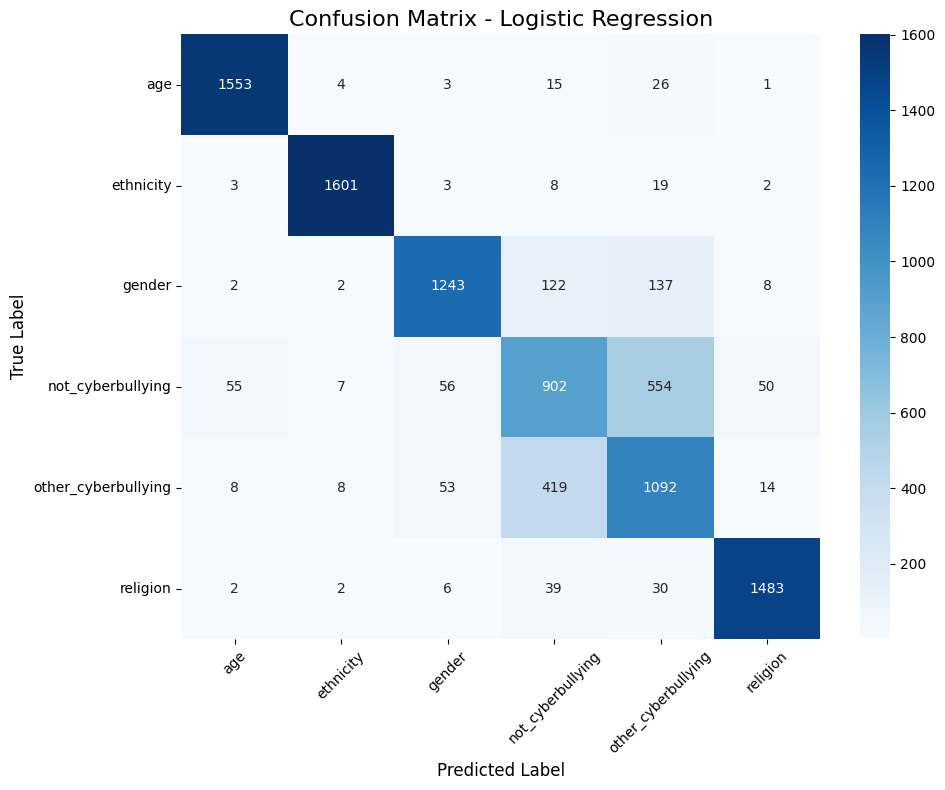


Your Comment: i hate gay people
1. Write your comment
2. Analyze your comment
3. Exit

POS_TAG
-i: JJ
-hate: VBP
-gay: JJ
-people: NNS

Prediction Comment: gender, Confidence: 91.48%

Your Comment: i hate gay people
1. Write your comment
2. Analyze your comment
3. Exit
Thanks for using the Cyberbullying Detector!


In [16]:
statement = ""
classifier = None
loaded_vectorizer = None

while True:
    if len(statement) == 0:
        print("\nYour Comment: -")
    else:
        print(f"\nYour Comment: {statement}")

    print("1. Write your comment")
    print("2. Analyze your comment")
    print("3. Exit")
    choice = input(">> ")

    if choice == "1":
        statement = write_statement()
        if os.path.exists(MODEL_PATH) and os.path.exists(VECTORIZER_PATH):
            with open(MODEL_PATH, "rb") as f:
                classifier = pickle.load(f)
            with open(VECTORIZER_PATH, "rb") as f:
                loaded_vectorizer = pickle.load(f)
            print("Loading Model and Vectorizer...")
        else:
            classifier, loaded_vectorizer = train_model()

    elif choice == "2":
        if classifier is None or loaded_vectorizer is None:
            print("\nPlease write a comment first to load/train the model!")
        else:
            analyze_statement(statement, classifier, loaded_vectorizer)

    elif choice == "3":
        print("Thanks for using the Cyberbullying Detector!")
        break
    else:
        print("Invalid input")